# Multi Agent Systems: A2 - Stochastic Search
#### Deadline: 23-04-2026, 12:00

You may hand in the assignment up to a day late, in which case the assignment grade will be capped at 8. For any extensions please contact the TAs.

Hand in the notebook file on Brightspace, name your file as follows: $\textbf{A2_yourname.ipynb}$

Studentname: Ella Kemperman \
Studentnumber:  s1119890


$\textit{Don't forget to label your axis and give your graphs titles!}$

In [1]:
import numpy as np
from numpy.random import uniform, normal
import matplotlib.pyplot as plt

from scipy.spatial import distance
np.random.seed(0)

### AI Disclaimer

There is no need to use AI such as LLM based chatbots in the assignments (unless
explicitly said otherwise). While the use of AI is not forbidden, whenever AI is used,
you are expected to report what model was used, where was it used in the assignment,
how, and for what purpose. Use the cell below to summarise your AI use. 

**Also note it if you did not use AI! If so, we expect to see absolutely no signs of AI use in your assignment.**

---
#### FILL THIS IN
**Did you use AI for this assignment?** no
---

## Part 0 - Evaluating PDFs (2 points)

As in assignment 1, **WE ASK YOU TO DO THE QUESTIONS IN PART 0 BY HAND AND UPLOAD A PHOTO OF YOUR NOTES TOGETHER WITH THE ASSIGNMENT!**

The $n$-th moment of a probability distribution $p(x)$ is:


$$M_n = \int_{-\infty}^{\infty} x^n p(x)\,dx$$

You might recognize the 1st and 2nd moments as the mean and variance of a distribution.

Evaluate the zeroth, first and second moment for the following PDFs. Also make a rough sketch of what you think the distribution to look like:

1. $p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{x^2}{2\sigma^2}\right)$
2. $p(x) = \begin{cases} \frac{1}{2a}, & x \in [-a,a] \\ 0, & \text{otherwise} \end{cases}$
3. $p(x) = \frac{2}{x^3}, x\geq 1 $

Additionally, evaluate for an arbitrary function $f(x)$ ($\delta(x)$ is the Dirac delta function):

4. $ \int_{-\infty}^{\infty} f(x)\,\delta(x-a)\,dx $
5. $ \int_{-\infty}^{\infty} (x^2+1)\,\delta(x-a)\,dx $
6. $ \int_{-\infty}^{t_0} f(t)\,\delta(t - t_0)\,dt $

---

## Part 0.5 - Helper functions (1 point)

In this assignment we will start to experiment with non-interacting and interacting stochastic agents, that are searching for something in a 2D world (although the term "search" might be a bit misleading in this case, as there is not much active searching going on). To do this neatly we are going to need some helper functions.

#### Periodic Boundary Condition

The first issue we might come across is that our agents wander off into the far distances of our world, which we do not really want. To solve this, we're going to use a periodic boundary condition: we define a square boundary, and when an agent leaves this boundary, it will come back on the opposite side. This way, the agents will never leave our world. Please define a function that takes a list of positions of agents and some tuple or list containing the boundary values, and returns an updated list of positions according to the periodic boundary condition. The exact way you implement this is up to you, keep in mind how you plan to keep track of your agent positions later on. You could also start with Part 1 first, and then come back when you have rough idea of how you are storing the positions of your agents.

#### Found target?

Secondly, we want a target that the agent is gonna search for. To do this, we want you to implement a function that takes a target position (2D coordinates), the coordinates of an agent/particle, and a radius. This function should return true when the agent is within the radius around the coordinate, false otherwise. You may, for example, use the $\textbf{scipy.spatial.distance}$ function for this.

In [2]:
def pbc(particles: np.ndarray, boundary_x: np.ndarray[float, float], boundary_y: np.ndarray[float, float]) -> np.ndarray:
    boundaries = np.stack([boundary_x, boundary_y])
    boundary_sums = np.diff(boundaries, axis=1).reshape(-1) * np.ones_like(particles)
    result = particles
    
    result[boundaries[:, 0] > particles] += boundary_sums[boundaries[:, 0] > particles]
    result[boundaries[:, 1] < particles] -= boundary_sums[boundaries[:, 1] < particles]
    return result

    
def in_radius(particles: np.ndarray, coordinates: np.ndarray, radius: float) -> np.ndarray:
    return np.sum((particles - coordinates)**2, axis=1)**0.5 < radius

---

## Part 1 - Non-interacting Stochastic Search

For the first part, we are going to look at how the Brownian particle and Active Brownian particle from the previous assignment perform when searching for a target (spoiler alert: bad). Use your code from the previous assignment (as inspiration) with low or average noise intensity, and incorporate the two helper functions you defined above.

PS. If you did not get the code working last time, or did not do the assignment, you may contact the TA (but see if you can figure it out yourself first of course).

#### 1.1 - Brownian Particles (0.5 points)

Let's first do this for Brownian particles. We have already provided the outline of a function that takes the amount of particles (n_particles), the target position as a tuple (target), and the radius from the target (r), as parameters, and creates an empty array that needs to be filled (the current shape is n x T x 2, but if you want to use something else that's up to you). Add the PBC, so that all particles stay within the boundaries, and and use your target finding code to keep track of the timesteps when an agent reaches the target. The function should return a list of all timesteps whenever a particle reaches the target for the first time (so do not include particles that reach the target multiple times) - for particles that do not reach the target use a value that makes it clear they never reached the target (e.g -1). Make sure your target is not too far from the starting position of the particles, and experiment a bit with the radius, but don't make it too large. Reminder of the numerical integration of the BP:

$x_{n+1} = x_n + \Delta_w$ with $\Delta_w \sim N(0, \Delta_t)$

After that, create the following:

* Plot the first responder time (so the arrival timestep of the first particle that reaches the target) as a function of the number of agents. For full points, for each number of agents, run it a few times, plot the average, and show the error-bars.
* Plot the number of agents that reached the target as a function of time for 10, 50 and 100 particles

In [3]:
def simulate_brownian_particles(n_particles, target, r, noise_scales=None):
    # example dt and timesteps, adjust as much as you want, but try to keep dt low
    dt = 0.01
    t = np.arange(0, 10 + dt, dt)
    
    # example boundary
    boundary_X = np.array([-5, 5])
    boundary_Y = np.array([-5, 5])

    # define initial conditions
    if noise_scales is None:
        noise_scales = np.ones((n_particles, 2))
    
    # initialize the array that will be filled in with the positions of the particle
    Xs = np.random.uniform(low=boundary_X[0], high=0, size=(n_particles, len(t) + 1, 2))
    end_times = np.full((n_particles,), t[-1])
    
    # simulate Brownian motion
    for i, t_ in enumerate(t):
        Xs[:, i + 1] = np.random.normal(Xs[:, i], noise_scales * np.sqrt(dt))
        Xs[:, i + 1] = pbc(Xs[:, i + 1], boundary_X, boundary_Y)
        at_goal = in_radius(Xs[:, i + 1], target, r)
        end_times[np.logical_and(at_goal, end_times == t[-1])] = t_

    return end_times

In [4]:
# YOUR PLOTTING CODE HERE
goal = np.array([2.5, 2.5])
radius = 2

particle_range = np.mgrid[10:100:5, 0:10][0]
get_first_responder_time = lambda n_particles: np.min(simulate_brownian_particles(n_particles, goal, radius))
first_responder_times = np.vectorize(get_first_responder_time)(particle_range)

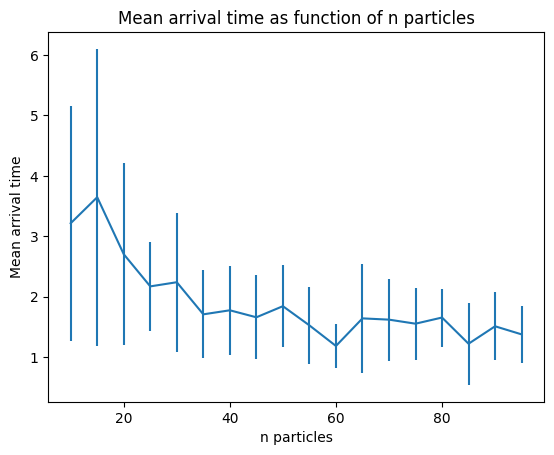

In [5]:
first_responder_means = np.mean(first_responder_times, axis=1)
first_responder_stds = np.std(first_responder_times, axis=1)

plt.figure()
plt.errorbar(particle_range[:, 0], first_responder_means, yerr=first_responder_stds)
plt.xlabel("n particles")
plt.ylabel("Mean arrival time")
plt.title("Mean arrival time as function of n particles")
plt.show()

[10.    9.21 10.    8.74 10.   10.   10.   10.   10.   10.  ]


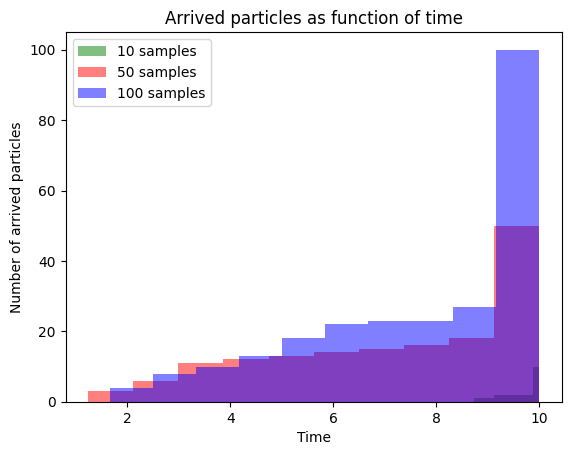

In [6]:
data_10, data_50, data_100 = simulate_brownian_particles(10, goal, radius), simulate_brownian_particles(50, goal, radius), simulate_brownian_particles(100, goal, radius)
print(data_10)
plt.figure()
plt.hist(data_10, cumulative=True, bins=10, alpha=0.5, label="10 samples", color="g")
plt.hist(data_50, cumulative=True, bins=10, alpha=0.5, label="50 samples", color="r")
plt.hist(data_100, cumulative=True, bins=10, alpha=0.5, label="100 samples", color="b")

plt.xlabel("Time")
plt.ylabel("Number of arrived particles")
plt.title("Arrived particles as function of time")
plt.xlim(0, 10)
plt.legend()
plt.show()

#### 1.2 - Active Brownian Particles (0.5 points)

Now do the exact same, but for Active Brownian particles. As a reminder:

$x_{n+1} = x_n + \Delta_t\hat{e}v_0$ \
$\theta_{n+1} = \theta_n + \Delta_w$ with $\Delta_w \sim N(0, \sqrt{\Delta_t}2)$ 

In [7]:
def simulate_active_brownian_particles(n_particles, target, r, noise_scales = None):
    # example dt and timesteps, adjust as much as you want, but try to keep dt low
    dt = 0.01
    t = np.arange(0, 10 + dt, dt)
    
    # example starting velocity
    v_0 = 2
    
    if noise_scales is None:
        noise_scales = np.ones(n_particles)
    
    boundary_X = np.array([-5, 5])
    boundary_Y = np.array([-5, 5])

    # you are allowed to change the shape to your needs
    Xs = np.random.uniform(low=boundary_X[0], high=0, size=(n_particles, len(t) + 1, 2))
    thetas = np.random.uniform(low=-np.pi, high=np.pi, size=(n_particles, len(t) + 1))
    
    end_times = np.full((n_particles,), t[-1])
    
    # simulate Brownian motion
    for i, t_ in enumerate(t):
        Xs[:, i + 1, :] = Xs[:, i, :] + v_0 * dt * np.array([np.cos(thetas[:, i]), np.sin(thetas[:, i])]).T
        Xs[:, i + 1] = pbc(Xs[:, i + 1], boundary_X, boundary_Y)
        thetas[:, i + 1] = np.random.normal(thetas[:, i], noise_scales * 2 * np.sqrt(dt))
        at_goal = in_radius(Xs[:, i + 1], target, r)
        end_times[np.logical_and(at_goal, end_times == t[-1])] = t_
        
    return end_times

In [8]:
# YOUR PLOTTING CODE HERE
goal = np.array([2.5, 2.5])
radius = 2

particle_range = np.mgrid[10:100:5, 0:10][0]
get_first_responder_time = lambda n_particles: np.min(simulate_active_brownian_particles(n_particles, goal, radius))
first_responder_times = np.vectorize(get_first_responder_time)(particle_range)

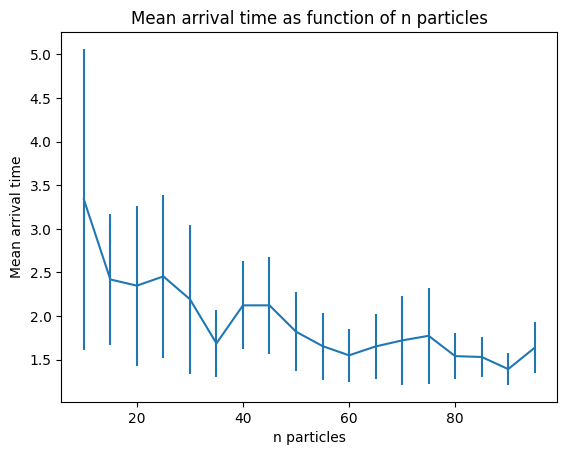

In [9]:
first_responder_means = np.mean(first_responder_times, axis=1)
first_responder_stds = np.std(first_responder_times, axis=1)

plt.figure()
plt.errorbar(particle_range[:, 0], first_responder_means, yerr=first_responder_stds)
plt.xlabel("n particles")
plt.ylabel("Mean arrival time")
plt.title("Mean arrival time as function of n particles")
plt.show()

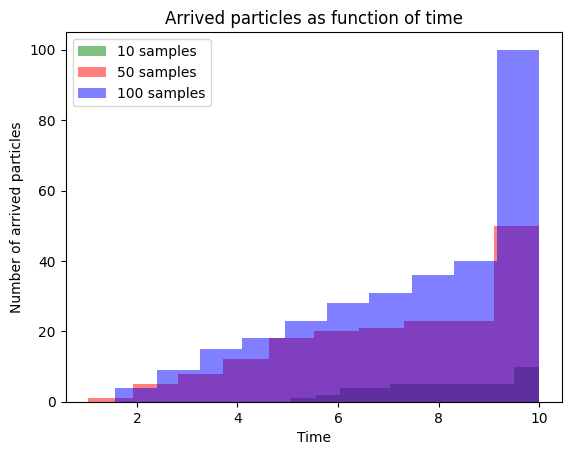

In [10]:
data_10, data_50, data_100 = simulate_active_brownian_particles(10, goal, radius), simulate_active_brownian_particles(50, goal, radius), simulate_active_brownian_particles(100, goal, radius)

plt.figure()
plt.hist(data_10, cumulative=True, bins=10, alpha=0.5, label="10 samples", color="g")
plt.hist(data_50, cumulative=True, bins=10, alpha=0.5, label="50 samples", color="r")
plt.hist(data_100, cumulative=True, bins=10, alpha=0.5, label="100 samples", color="b")

plt.xlabel("Time")
plt.ylabel("Number of arrived particles")
plt.title("Arrived particles as function of time")
plt.xlim(0, 10)
plt.legend()
plt.show()

---

## Part 2 - Interacting Stochastic Particles 

Now, before we are going to look at interacting stochastic search, let us first implement interacting particles and look at their behaviour. Like before, please use the periodic boundary condition to make sure the particles stay within the boundaries.

Note that for this to work, all particles need to be simulated at the same time, so you cannot simulate a trajectory, then another one, then another one, etc. It is therefore advised to store the values in a multidimensional array (like shown in 1.1), and update them simultanously. Make sure you are familair with slicing and indexing of numpy arrays, as this will make your life a lot easier! The code you wrote for Part 1 should provide you with a very good starting point.  

#### 2.1 - Flocking (1.5 points)

The first type of interacting particles we'll be looking at are the flocking particles. We will still be using most of the ABP behaviour, but now we will add interacting behaviour. The particle (agent) will look at its surrounding, specifically at all particles in radius $r$, and will update its $\theta$ according to the average orientation of all particles around it (including itself). Use the following update rules:

$x_{n+1} = x_n + \Delta_t\hat{e}v_0$ \
$\theta_{n+1} = \left< \theta_n \right>_r + \Delta_w$ with $\Delta_w \sim N(0, \sqrt{\Delta_t}2)$ \
$\left< \theta_n \right>_r = arctan[\dfrac{\left<sin(\theta_n)\right>_r}{\left<cos(\theta_n)\right>_r}] $ 

Like before, write a function that takes a number of agents, and simulates that many agents. The radius in which the agent is looking around itself should also be a parameter passed to the function. Keep track of the agents' position and orientation at every time step, and return both arrays. No need for any searching yet.

Make sure to uniformly spread the agents around the world (within the boundaries of course, use $\textbf{np.random.uniform}$), and give each agent a random starting orientation (also uniformly, what are the boundaries of the starting orientation?).

I would recommend writing an additional function that updates the $\theta$ of a specific agent, that loops over all other $\theta$s and keeps track of which ones are in range. To see whether another agent is in range, you should be able to re-use the code you wrote to check whether an agent is close enough to the target.

In [11]:
# YOUR CODE HERE
def update_thetas(Xs: np.ndarray, thetas: np.ndarray, r: float) -> np.ndarray:
    result = np.zeros_like(thetas)
    for i in range(thetas.shape[0]):
        in_range = in_radius(Xs, Xs[i], r)
        # Using arctan formulation broke the code and bounded thetas to [-1/2pi, 1/2pi]. This formulation shows flocking better.
        result[i] = np.mean(thetas[in_range])  # np.arctan(np.mean(np.sin(thetas[in_range]) / np.cos(thetas[in_range])))
    return result

def simulate_flocking_brownian_particles(n_particles: int, r: float, noise_scales = None):
    # example dt and timesteps, adjust as much as you want, but try to keep dt low
    dt = 0.01
    t = np.arange(0, 10 + dt, dt)
    
    # example starting velocity
    v_0 = 2
    
    boundary_X = np.array([-5, 5])
    boundary_Y = np.array([-5, 5])
    
    if noise_scales is None:
        noise_scales = np.ones(n_particles)
    
    # you are allowed to change the shape to your needs
    Xs = np.random.uniform(low=boundary_X[0], high=boundary_X[1], size=(n_particles, len(t) + 1, 2))
    thetas = np.random.uniform(low=-np.pi, high=np.pi, size=(n_particles, len(t) + 1))
    
    # simulate Brownian motion
    for i, t_ in enumerate(t):
        Xs[:, i + 1, :] = Xs[:, i, :] + v_0 * dt * np.array([np.cos(thetas[:, i]), np.sin(thetas[:, i])]).T
        Xs[:, i + 1] = pbc(Xs[:, i + 1], boundary_X, boundary_Y)
        thetas[:, i + 1] = np.random.normal(update_thetas(Xs[:, i + 1, :], thetas[:, i], r), noise_scales * 2 * np.sqrt(dt))
        
    return Xs, thetas

## Intermezzo - animating your particles

In the following sections you will often be asked about the behaviour of your particles. You can try to reason about this (which is also suggested!), but you can also plot their behaviour. As you work with a large number of particles, it is very difficult to see what's going one if you just plot their trajectories all at once. We therefore provide a nice little widget below, which could help you see what is happening with your particles.

The code below animates your particles in such a way that you can use the slider to go through time, and for every timestep the previous 20 timesteps are printed as well. This way you can see the evolution of your particles over time, without them leaving behind a trajectory. If you followed the original way of storing your positions (array of n_particles x T x 2, you should not have to change anything, otherwise you might need to make a few changes). Please use this code anywhere you need in this notebook, by just adding extra cells and pasting it in. Make sure you take a moment to try and understand it, so that you can make any changes later if needed.

interactive(children=(IntSlider(value=1, description='w', max=1002), Output()), _dom_classes=('widget-interact…

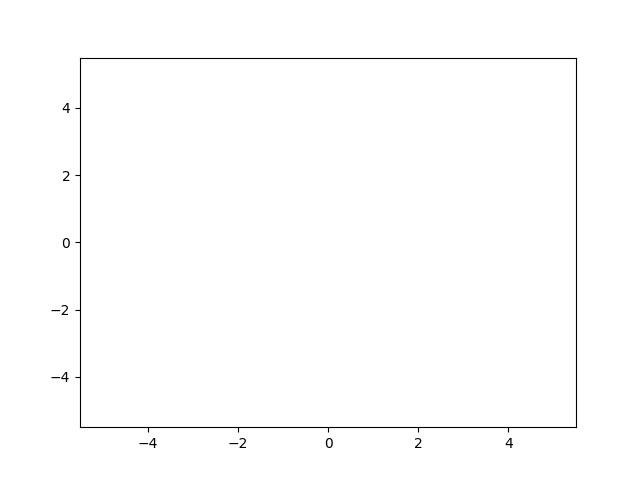

In [12]:
%matplotlib widget
from ipywidgets import interact

particles_pos = simulate_flocking_brownian_particles(100, 0.5)[0]

lines = []

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)

# for each particle, get the line of their trajectory
for i in range(len(particles_pos)):
    line, = ax.plot(particles_pos[i,:,0], particles_pos[i,:,1])
    lines.append(line)

def update(w=1):
    # for each particle, plot the current and previous 20 timesteps when updated
    for i, line in enumerate(lines):
        line.set_ydata(particles_pos[i, w-20:w, 1])
        line.set_xdata(particles_pos[i, w-20:w, 0])
    fig.canvas.draw()

# create the widget, and a slider that starts at 0, ends at T (total amount of timesteps), and takes steps of 1
interact(update, w=(0, len(particles_pos[0]), 1))
plt.show()

#### 2.2 - Flocking behaviour (0.5 points)

Using the function you just defined, please plot the following:

1. The last 20 timesteps of 100 particles (with $r = 1$) (if you do not see any interesting results, play around with your noise and velocity)
2. The mean and std of the final orientation of all particles, as a function of $r$ (e.g 0.1 - 10), for 30 particles
3. The mean and std of the final orientation of all particles, as a function of the number of particles (e.g 10-100) (choose a suitable $r$)

What do you see? Why does this happen?

Text(0.5, 1.0, '2D Flocking')

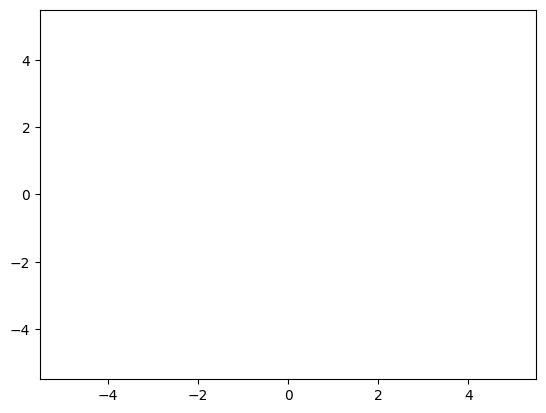

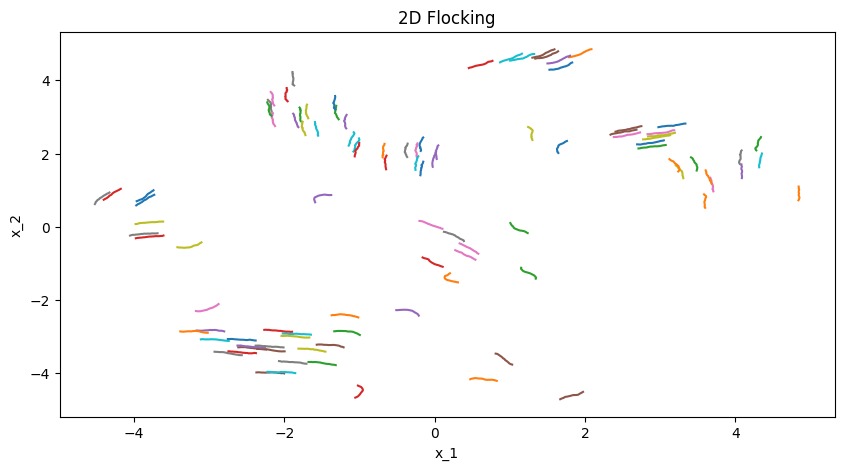

In [13]:
# YOUR CODE HERE
%matplotlib inline

plt.figure(figsize = (10,5))
for i in range(particles_pos.shape[0]):
    plt.plot(particles_pos[i, -20:, 0], particles_pos[i, -20:, 1])
plt.xlabel("x_1")
plt.ylabel("x_2")
plt.title("2D Flocking")

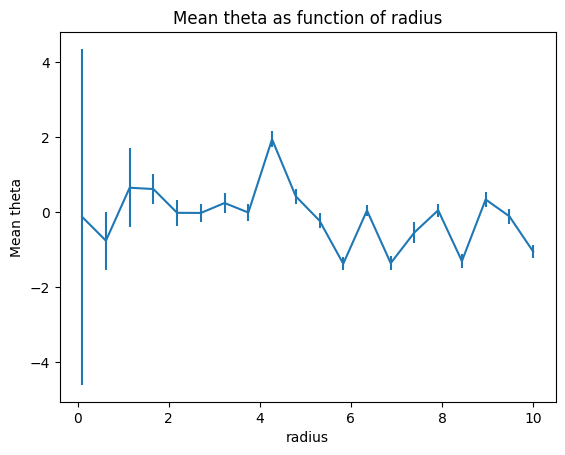

In [14]:
r_range = np.linspace(0.1, 10, 20)
means = np.zeros_like(r_range)
stds = np.zeros_like(r_range)

for i, r in enumerate(r_range):
    thetas = simulate_flocking_brownian_particles(30, r)[1]
    means[i] = np.mean(thetas[:, -1])
    stds[i] = np.std(thetas[:, -1])
    
plt.figure()
plt.errorbar(r_range, means, yerr=stds)
plt.xlabel("radius")
plt.ylabel("Mean theta")
plt.title("Mean theta as function of radius")
plt.show()

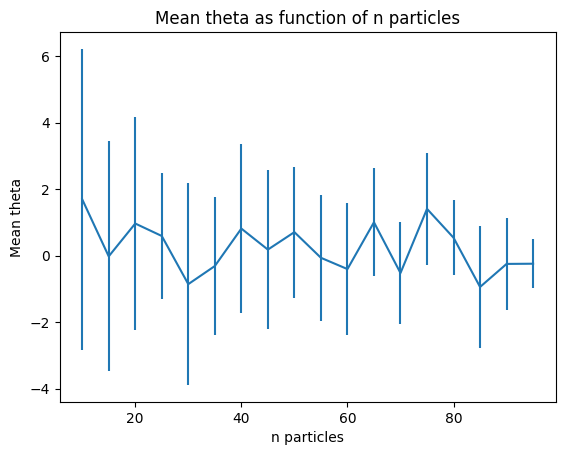

In [15]:
radius = 0.5
particle_range = np.arange(10, 100, 5)
means = np.zeros_like(particle_range, dtype=float)
stds = np.zeros_like(particle_range, dtype=float)

for i, n in enumerate(particle_range):
    thetas = simulate_flocking_brownian_particles(n, radius)[1]
    means[i] = np.mean(thetas[:, -1])
    stds[i] = np.std(thetas[:, -1])

plt.figure()
plt.errorbar(particle_range, means, yerr=stds)
plt.xlabel("n particles")
plt.ylabel("Mean theta")
plt.title("Mean theta as function of n particles")
plt.show()

The standard deviation gets less the higher the radius. This is logical, as a higher radius means the angles flock together more, so there is less variation in angle as all particles have the same base angle and only the noise is added.
For more particles, the standard deviation also decreases, which is also logical, as more particles means that it happens more often that particles are 'connected' to all more other particles due to radius chaining, causing the angle to be more similar.

#### 2.3 - Motility-induced phase separation (1.5 points)

Now, instead of aligning with the orientation of other particles, they now slow down when close to one another, and speed up when farther away from one another (meaning their nominal speed depends on their local concentration). It again follows the basic behaviour of an ABP, but now with a change in velocity:

$v_{n+1} = v_0 * exp(-N_r / a)$

Here, $N_r$ is the amount of particles in radius $r$, and $a$ is a constant that you define yourself (e.g. 5, but experiment a bit yourself). This gives an exponential slow down with the number of agents nearby. 

In [16]:
# YOUR CODE HERE
def velocity_update(Xs: np.ndarray, r: float, a: float, modifier: np.ndarray = None) -> np.ndarray:
    if modifier is None:
        modifier = np.zeros(Xs.shape[0])
    result = np.zeros(Xs.shape[0])
    for i in range(Xs.shape[0]):
        in_range = np.sum(in_radius(Xs, Xs[i], r)) + modifier[i]
        result[i] = np.exp(-in_range / a)
    return result


def simulate_velocity_brownian_particles(n_particles: int, r: float, a: float, noise_scales = None):
    # example dt and timesteps, adjust as much as you want, but try to keep dt low
    dt = 0.01
    t = np.arange(0, 10 + dt, dt)
    
    # example starting velocity
    v_0 = 2
    
    boundary_X = np.array([-5, 5])
    boundary_Y = np.array([-5, 5])
    
    if noise_scales is None:
        noise_scales = np.ones(n_particles)
    
    # you are allowed to change the shape to your needs
    Xs = np.random.uniform(low=boundary_X[0], high=0, size=(n_particles, len(t) + 1, 2))
    thetas = np.random.uniform(low=-np.pi, high=np.pi, size=(n_particles, len(t) + 1))
    vs = np.zeros((n_particles, len(t)))
    
    # simulate Brownian motion
    for i, t_ in enumerate(t):
        vs[:, i] = velocity_update(Xs[:, i], r, a)
        Xs[:, i + 1, :] = Xs[:, i, :] + v_0 * vs[:, i].reshape(-1, 1) * dt * np.array([np.cos(thetas[:, i]), np.sin(thetas[:, i])]).T
        Xs[:, i + 1] = pbc(Xs[:, i + 1], boundary_X, boundary_Y)
        thetas[:, i + 1] = np.random.normal(thetas[:, i], noise_scales * 2 * np.sqrt(dt))

    return Xs, thetas

#### 2.4 - Motility-induced phase separation behaviour (0.5 points)

Please scatter the final position of all particles on a plot, and do that three times: for 10, 50, and 100 particles. What do you see? Why does this happen?

Text(0.5, 1.0, 'Final positions of motility-induced particles')

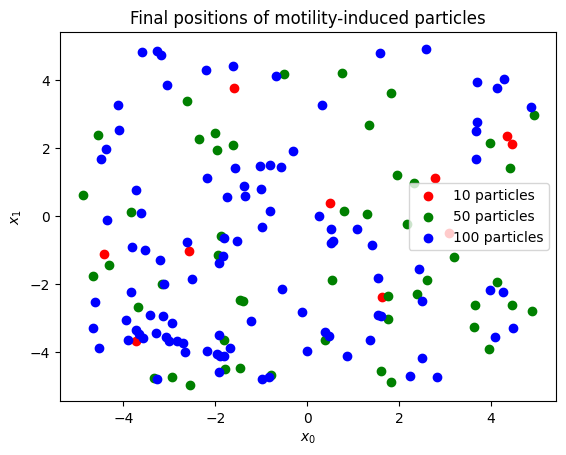

In [17]:
# YOUR CODE HERE
a = 10
radius = 1
data_10, data_50, data_100 = simulate_velocity_brownian_particles(10, radius, a)[0], simulate_velocity_brownian_particles(50, radius, a)[0], simulate_velocity_brownian_particles(100, radius, a)[0]

plt.figure()
plt.scatter(data_10[:, -1, 0], data_10[:, -1, 1], c="r", label="10 particles")
plt.scatter(data_50[:, -1, 0], data_50[:, -1, 1], c="g", label="50 particles")
plt.scatter(data_100[:, -1, 0], data_100[:, -1, 1], c="b", label="100 particles")
plt.legend()
plt.xlabel(r"$x_0$")
plt.ylabel(r"$x_1$")
plt.title("Final positions of motility-induced particles")

Small groups of particles seem to be forming at places where other particles are. This likely happens because particles get really slow when they are near each other, so they can't easily escape each other's 'gravity'.

---

## Part 3 - Interacting Stochastic Search

Finally, we'll combine everything we did up until now. Use the code from the previous section and adapt it so that the particles can find a target. Like in the first assignment, make it return a list of timesteps of first contact with the target. Particles that never reach the target should again be represented by the maximum number of timesteps.

#### 3.1 - Flocking search (1 points)

Please simulate the search when particles are flocking (changing orientation when other particles are close by). Make sure that the target is not in the same area the particles are uniformly distributed in, so for example, if you're using (-5, 5) boundaries, randomly place your particles somewhere between X=(-5, 0) and Y=(-5, 0), and your target at (2.5, 2.5). Use the same target radius as you did in Part 1.

Like before, to help you understand how time and the number of agents influence the search when particles show flocking behaviour, do the following:

* Plot the first responder time (so the arrival timestep of the first particle that reaches the target) as a function of the number of agents. For full points, for each number of agents, run it a few times, plot the average, and show the error-bars.
* Plot the number of agents that reached the target as a function of time for 10, 50 and 100 particles

Comment on the differences with purely stochastic search, and on what you think is happening. You can always use the animation widget showed earlier on to help you better understand what's going on! If you want to that, I would recommend adding a circle representing the target location.

In [18]:
# YOUR CODE HERE
def simulate_flocking_goal_particles(n_particles, target, target_r, r, noise_scales = None):
    # example dt and timesteps, adjust as much as you want, but try to keep dt low
    dt = 0.01
    t = np.arange(0, 10 + dt, dt)
    
    # example starting velocity
    v_0 = 2
    
    if noise_scales is None:
        noise_scales = np.ones(n_particles)
    
    boundary_X = np.array([-5, 5])
    boundary_Y = np.array([-5, 5])

    # you are allowed to change the shape to your needs
    Xs = np.random.uniform(low=boundary_X[0], high=0, size=(n_particles, len(t) + 1, 2))
    thetas = np.random.uniform(low=-np.pi, high=np.pi, size=(n_particles, len(t) + 1))
    
    end_times = np.full((n_particles,), t[-1])
    
    # simulate Brownian motion
    for i, t_ in enumerate(t):
        Xs[:, i + 1, :] = Xs[:, i, :] + v_0 * dt * np.array([np.cos(thetas[:, i]), np.sin(thetas[:, i])]).T
        Xs[:, i + 1] = pbc(Xs[:, i + 1], boundary_X, boundary_Y)
        thetas[:, i + 1] = np.random.normal(update_thetas(Xs[:, i + 1, :], thetas[:, i], r), noise_scales * 2 * np.sqrt(dt))
        at_goal = in_radius(Xs[:, i + 1], target, target_r)
        end_times[np.logical_and(at_goal, end_times == t[-1])] = t_
        
    return end_times

In [19]:
# YOUR PLOTTING CODE HERE
goal = np.array([2.5, 2.5])
radius = 2
flocking_radius = 0.5

particle_range = np.mgrid[10:100:5, 0:10][0]
get_first_responder_time = lambda n_particles: np.min(simulate_flocking_goal_particles(n_particles, goal, radius, flocking_radius))
first_responder_times = np.vectorize(get_first_responder_time)(particle_range)

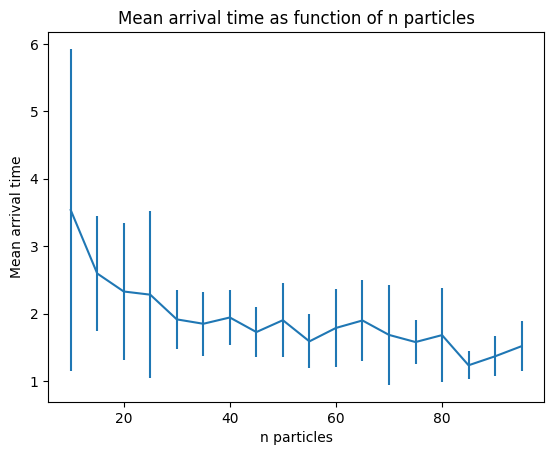

In [20]:
first_responder_means = np.mean(first_responder_times, axis=1)
first_responder_stds = np.std(first_responder_times, axis=1)

plt.figure()
plt.errorbar(particle_range[:, 0], first_responder_means, yerr=first_responder_stds)
plt.xlabel("n particles")
plt.ylabel("Mean arrival time")
plt.title("Mean arrival time as function of n particles")
plt.show()

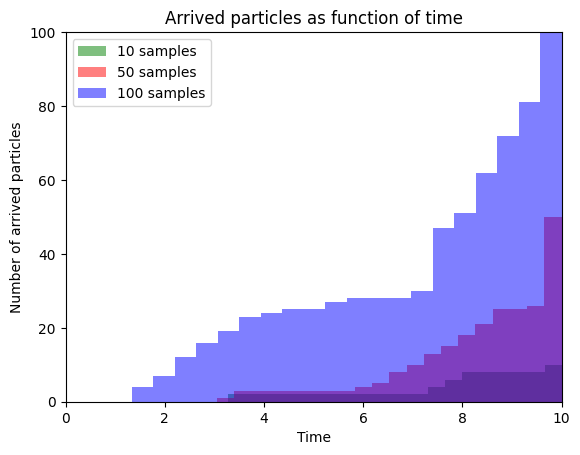

In [21]:
data_10, data_50, data_100 = simulate_flocking_goal_particles(10, goal, radius, flocking_radius), simulate_flocking_goal_particles(50, goal, radius, radius, flocking_radius), simulate_flocking_goal_particles(100, goal, radius, flocking_radius)

plt.figure()
plt.hist(np.ma.masked_invalid(data_10), cumulative=True, bins=20, alpha=0.5, label="10 samples", color="g")
plt.hist(np.ma.masked_invalid(data_50), cumulative=True, bins=20, alpha=0.5, label="50 samples", color="r")
plt.hist(np.ma.masked_invalid(data_100), cumulative=True, bins=20, alpha=0.5, label="100 samples", color="b")

plt.xlabel("Time")
plt.ylabel("Number of arrived particles")
plt.title("Arrived particles as function of time")
plt.ylim(0, 100)
plt.xlim(0, 10)
plt.legend()
plt.show()

A lot more particles seem to be arriving simultaneously compared to stochastic search, likely caused by flocks of particles arriving at the goal together

#### 3.2 - Motility-induced search (1 points)

Please simulate the search when particles change velocity when other particles are close by. To make this interesting in a search context, the particle should also to start slow down when it reaches the target, and not only when it gets close to other particles. For sake of ease, whenever a particle is within the target radius, treat it as if there are 3 additional particles in its range. Again, make sure the initial positions are not too close to the target, and use the same target radius as before.

And again:

* Plot the first responder time (so the arrival timestep of the first particle that reaches the target) as a function of the number of agents. For full points, for each number of agents, run it a few times, plot the average, and show the error-bars.
* Plot the number of agents that reached the target as a function of time for 10, 50 and 100 particles

Comment on the differences with purely stochastic search, and on what you think is happening.

In [22]:
# YOUR CODE HERE
def simulate_velocity_goal_particles(n_particles: int, target: np.ndarray[float, float], target_r: float, r: float, a: float, noise_scales = None):
    # example dt and timesteps, adjust as much as you want, but try to keep dt low
    dt = 0.01
    t = np.arange(0, 10 + dt, dt)
    
    # example starting velocity
    v_0 = 2
    
    boundary_X = np.array([-5, 5])
    boundary_Y = np.array([-5, 5])
    
    if noise_scales is None:
        noise_scales = np.ones(n_particles)
    
    # you are allowed to change the shape to your needs
    Xs = np.random.uniform(low=boundary_X[0], high=0, size=(n_particles, len(t) + 1, 2))
    thetas = np.random.uniform(low=-np.pi, high=np.pi, size=(n_particles, len(t) + 1))
    vs = np.zeros((n_particles, len(t)))
    
    end_times = np.full((n_particles,), t[-1])
    # simulate Brownian motion
    for i, t_ in enumerate(t):
        at_goal = in_radius(Xs[:, i], target, target_r)
        end_times[np.logical_and(at_goal, end_times == t[-1])] = t_
        vs[:, i] = velocity_update(Xs[:, i], r, a, modifier=3 * at_goal)

        Xs[:, i + 1, :] = Xs[:, i, :] + v_0 * vs[:, i].reshape(-1, 1) * dt * np.array([np.cos(thetas[:, i]), np.sin(thetas[:, i])]).T
        Xs[:, i + 1] = pbc(Xs[:, i + 1], boundary_X, boundary_Y)
        thetas[:, i + 1] = np.random.normal(thetas[:, i], noise_scales * 2 * np.sqrt(dt))
        
    return end_times

In [23]:
# YOUR PLOTTING CODE HERE
goal = np.array([2.5, 2.5])
radius = 2
flocking_radius = 0.1
a = 3

particle_range = np.mgrid[10:100:5, 0:10][0]
get_first_responder_time = lambda n_particles: np.min(simulate_velocity_goal_particles(n_particles, goal, radius, flocking_radius, a))
first_responder_times = np.vectorize(get_first_responder_time)(particle_range)

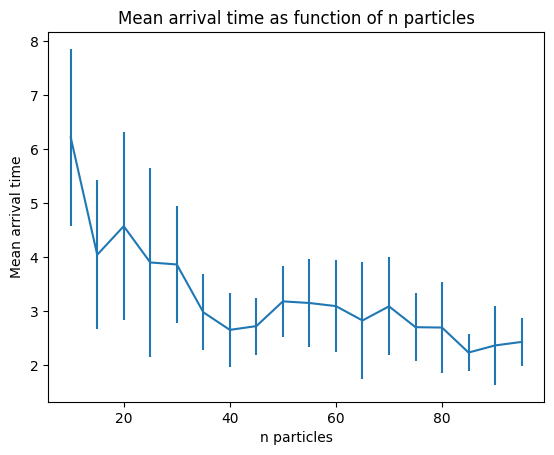

In [24]:
first_responder_means = np.mean(first_responder_times, axis=1)
first_responder_stds = np.std(first_responder_times, axis=1)

plt.figure()
plt.errorbar(particle_range[:, 0], first_responder_means, yerr=first_responder_stds)
plt.xlabel("n particles")
plt.ylabel("Mean arrival time")
plt.title("Mean arrival time as function of n particles")
plt.show()

()


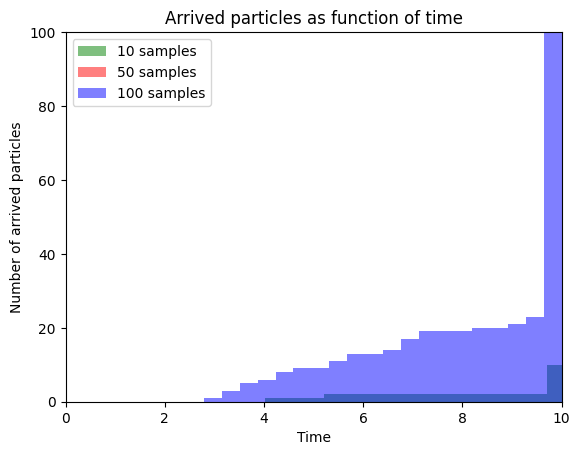

In [25]:
data_10, data_50, data_100 = simulate_velocity_goal_particles(10, goal, radius, flocking_radius, a), simulate_velocity_goal_particles(50, goal, radius, radius, flocking_radius, a), simulate_velocity_goal_particles(100, goal, radius, flocking_radius, a)
print(data_10[0].shape)
plt.figure()
plt.hist(data_10, cumulative=True, bins=20, alpha=0.5, label="10 samples", color="g")
plt.hist(np.ma.masked_invalid(data_50), cumulative=True, bins=20, alpha=0.5, label="50 samples", color="r")
plt.hist(np.ma.masked_invalid(data_100), cumulative=True, bins=20, alpha=0.5, label="100 samples", color="b")

plt.xlabel("Time")
plt.ylabel("Number of arrived particles")
plt.title("Arrived particles as function of time")
plt.xlim(0, 10)
plt.ylim(0, 100)
plt.legend()
plt.show()

The particles don't really seem to be arriving at the goal. I think this is caused by them slowing each other down too much, therefore not really travelling far and hitting the goal. 